In [30]:
import sys
print(sys.executable)

c:\Users\AnneB\AppData\Local\Programs\Python\Python312\python.exe


In [31]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops

In [32]:
full = pd.read_csv("inventaire_oasis1.csv")
tissue_3d = pd.read_csv("biomarkers_tissue_volumes.csv")
print(f"{len(full)} sujets dans l'inventaire, {len(tissue_3d)} avec biomarqueurs 3D.")

485 sujets dans l'inventaire, 485 avec biomarqueurs 3D.


In [33]:
def load_volume(subject_path):
    t88_dir = os.path.join(subject_path, "PROCESSED", "MPRAGE", "T88_111")
    candidates = glob.glob(os.path.join(t88_dir, "*.img")) + \
                 glob.glob(os.path.join(t88_dir, "*.nii*"))
    if not candidates:
        raise FileNotFoundError(f"Aucun volume trouvé dans {t88_dir}")
    img = nib.load(candidates[0])
    return np.squeeze(img.get_fdata()), img.header.get_zooms()[:3]
 
 
def load_fsl_seg(subject_path):
    seg_dir = os.path.join(subject_path, "FSL_SEG")
    candidates = glob.glob(os.path.join(seg_dir, "*.img")) + \
                 glob.glob(os.path.join(seg_dir, "*.nii*"))
    if not candidates:
        raise FileNotFoundError(f"Aucune segmentation trouvée dans {seg_dir}")
    img = nib.load(candidates[0])
    return np.squeeze(img.get_fdata())

In [34]:
def central_axial_slice(volume):
    """Retourne la coupe axiale centrale (plan le plus courant pour ce type d'analyse)."""
    z = volume.shape[2] // 2
    return volume[:, :, z]

In [35]:
def compute_slice_areas(seg_slice, pixel_dims):
    """
    Convertit les labels de la coupe 2D en aires (cm²).
    Convention : 0=fond, 1=LCR, 2=matière grise, 3=matière blanche.
    """
    pixel_area_mm2 = pixel_dims[0] * pixel_dims[1]
    labels, counts = np.unique(seg_slice.astype(int), return_counts=True)
    label_names = {0: "background", 1: "csf", 2: "gray_matter", 3: "white_matter"}
    areas = {}
    for label, count in zip(labels, counts):
        name = label_names.get(label, f"label_{label}")
        areas[f"{name}_area_cm2"] = count * pixel_area_mm2 / 100.0  # mm² -> cm²
    return areas

In [36]:
def compute_asymmetry(seg_slice):
    """
    Compare le nombre de pixels de matière grise/blanche entre hémisphère
    gauche et droit (découpage au milieu de l'axe x, cerveau centré par T88).
    Retourne un indice d'asymétrie : (gauche - droite) / (gauche + droite).
    """
    mid = seg_slice.shape[0] // 2
    left = seg_slice[:mid, :]
    right = seg_slice[mid:, :]
 
    def asym_index(label):
        left_count = np.sum(left == label)
        right_count = np.sum(right == label)
        total = left_count + right_count
        return (left_count - right_count) / total if total > 0 else np.nan
 
    return {
        "asymmetry_gray_matter": asym_index(2),
        "asymmetry_white_matter": asym_index(3),
    }
 

In [ ]:
def compute_radiomic_features(volume_slice, brain_mask):
    """Calcule des statistiques d'intensité et de texture sur le cerveau uniquement."""
    brain_pixels = volume_slice[brain_mask > 0]
    if brain_pixels.size == 0:
        return {}

    features = {
        "intensity_mean": float(np.mean(brain_pixels)),
        "intensity_std": float(np.std(brain_pixels)),
        "intensity_skew": float(skew(brain_pixels)),
        "intensity_kurtosis": float(kurtosis(brain_pixels)),
    }

    norm = volume_slice.copy()
    norm[brain_mask == 0] = 0
    norm = (255 * (norm - norm.min()) / (np.ptp(norm) + 1e-8)).astype(np.uint8)  
    glcm = graycomatrix(norm, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features["texture_contrast"] = float(graycoprops(glcm, "contrast")[0, 0])
    features["texture_homogeneity"] = float(graycoprops(glcm, "homogeneity")[0, 0])
    features["texture_energy"] = float(graycoprops(glcm, "energy")[0, 0])

    return features

Aires 2D (cm²) : {'background_area_cm2': np.float64(182.15), 'csf_area_cm2': np.float64(21.81), 'gray_matter_area_cm2': np.float64(86.3), 'white_matter_area_cm2': np.float64(75.82)}
Asymétrie : {'asymmetry_gray_matter': np.float64(0.01993047508690614), 'asymmetry_white_matter': np.float64(-0.020575046161962544)}
Radiomique : {'intensity_mean': 976.4738759310608, 'intensity_std': 327.1251191292786, 'intensity_skew': -0.44490057216776735, 'intensity_kurtosis': -0.7813590566535016, 'texture_contrast': 222.20734519104087, 'texture_homogeneity': 0.5520555578346267, 'texture_energy': 0.4914565756206674}


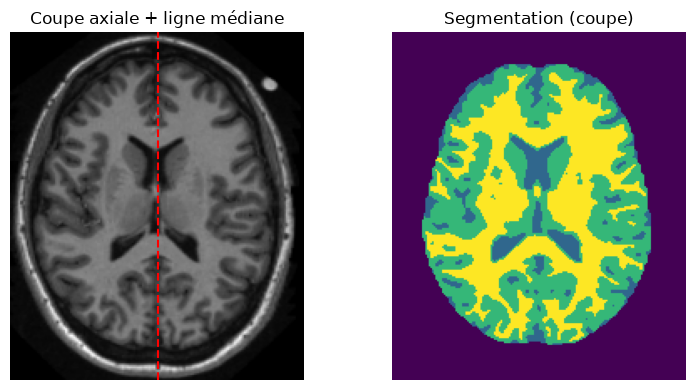

In [43]:
example = full[full["has_T88"] & full["has_FSL_SEG"]].iloc[0]
volume, voxel_dims = load_volume(example["path"])
seg = load_fsl_seg(example["path"])
 
vol_slice = central_axial_slice(volume)
seg_slice = central_axial_slice(seg)
 
areas = compute_slice_areas(seg_slice, voxel_dims)
asymmetry = compute_asymmetry(seg_slice)
radiomics = compute_radiomic_features(vol_slice, brain_mask=(seg_slice > 0))
 
print("Aires 2D (cm²) :", areas)
print("Asymétrie :", asymmetry)
print("Radiomique :", radiomics)
 
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(vol_slice.T, cmap="gray", origin="lower")
axes[0].axvline(vol_slice.shape[0] // 2, color="red", linestyle="--")
axes[0].set_title("Coupe axiale + ligne médiane")
axes[1].imshow(seg_slice.T, cmap="viridis", origin="lower")
axes[1].set_title("Segmentation (coupe)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()